#  Generate daily BRAN2023 regional output - issue #3

##### https://github.com/shared-climate-data-problems/BRAN-reanalysis/issues/3

In [2]:
Author = {"name": "Thomas Moore", "affiliation": "CSIRO", "email": "thomas.moore@csiro.au", "orcid": "0000-0003-3930-1946"}

In [15]:
import intake
import xarray as xr
import pandas as pd
import numpy as np
from dask.distributed import Client, LocalCluster
import dask
import datetime
import os
import configparser
import matplotlib.pyplot as plt
import glob
from pprint import pprint  

# warnings off

In [25]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="dask")

# Cluster

In [4]:
cluster=LocalCluster(n_workers=28,processes=True,threads_per_worker=1)
#cluster=LocalCluster()
client = Client(cluster)

# cookie cutter settings

In [13]:
product_request_str = '2023' # 2020, 2023
var_request_list = ['u','v','temp']
frequency_request_str = 'daily' # daily, month, annual, static
date_range_dict = {'date_start':'ALL','date_end':'ALL'}
region_range_dict = {'lat':(-20,20),'lon':(100,179)}

# load BRAN2023 objects

### base path

In [14]:
netcdf_base_path = '/g/data/gb6/BRAN/BRAN'+product_request_str+'/'+frequency_request_str+'/'
netcdf_base_path

'/g/data/gb6/BRAN/BRAN2023/daily/'

# loop variables here

In [16]:
i=2

### file list

In [17]:
# 1. Glob the files (returns a Python list)
filename_pattern = 'ocean_'+var_request_list[i]+'*.nc'
pattern = netcdf_base_path+filename_pattern
file_list = sorted(glob.glob(pattern))

In [24]:
%%time
ds = xr.open_mfdataset(file_list, parallel=True)

/g/data/es60/users/thomas_moore/miniconda3/envs/pangeo_csepta/lib/python3.10/site-packages/dask/utils.py:78: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  return func(*args, **kwargs)
/g/data/es60/users/thomas_moore/miniconda3/envs/pangeo_csepta/lib/python3.10/site-packages/dask/utils.py:78: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  return func(*args, **kwargs)
/g/data/es60/users/thomas_moore/miniconda3/envs/pangeo_csepta/lib/python3.10/site-packages/dask/utils.py:78: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  return func(*ar

CPU times: user 25.2 s, sys: 2.53 s, total: 27.7 s
Wall time: 27.4 s


In [ ]:
config = configparser.ConfigParser()
config.read('/g/data/es60/users/thomas_moore/code/BRAN2020-intake-catalog/config.ini')
# Get the value of a variable
catalog_path = config.get('paths', 'catalog_path')
#
BRAN2020_catalog = intake.open_esm_datastore(catalog_path+'BRAN2020.json',columns_with_iterables=['variable'])

In [ ]:
var_request_list = ['temp','salt']
time_period_request_list = ['daily']

In [ ]:
search = BRAN2020_catalog.search(variable=var_request_list,time_period=time_period_request_list)

In [ ]:
xarray_open_kwargs = {"chunks": {"Time": -1,'st_ocean':10}}

In [ ]:
DS_TS=search.to_dask(xarray_open_kwargs=xarray_open_kwargs)
DS_TS

# filter time

In [ ]:
sel_dict_time = {'Time':slice('January 2010','December 2022')}
sel_dict_xz = {'xt_ocean':slice(153.5,155.2),'st_ocean':slice(0,1500)}
sel_dict_y = {'yt_ocean':-27}

In [ ]:
EAC_TS = DS_TS.sel(sel_dict_time).sel(sel_dict_y,method='nearest').sel(sel_dict_xz)

In [ ]:
EAC_TS

# velocities

In [ ]:
var_request_list = ['u','v']
time_period_request_list = ['daily']

In [ ]:
search = BRAN2020_catalog.search(variable=var_request_list,time_period=time_period_request_list)

In [ ]:
DS_uv=search.to_dask(xarray_open_kwargs=xarray_open_kwargs)
DS_uv

In [ ]:
sel_dict_time = {'Time':slice('January 2010','December 2022')}
sel_dict_xz = {'xu_ocean':slice(153.5,155.2),'st_ocean':slice(0,1500)}
sel_dict_y = {'yu_ocean':-27}

In [ ]:
EAC_uv = DS_uv.sel(sel_dict_time).sel(sel_dict_y,method='nearest').sel(sel_dict_xz)

In [ ]:
EAC_uv

# write to `netcdf` files 

In [4]:
write_path = '/g/data/es60/users/thomas_moore/EAC_BRAN_slices/'

In [ ]:
encoding = {
    'u': {
        'chunksizes': (4748, 42, 18)  # setting chunk size to entire dimension lengths
    },
    'v':{
        'chunksizes': (4748, 42, 18) # setting chunk size to entire dimension lengths
}
}


In [ ]:
%%time
EAC_uv.to_netcdf(write_path+'EAC_mooring_BRAN2020_uv.nc',encoding=encoding)

In [ ]:
encoding = {
    'temp': {
        'chunksizes': (4748, 42, 17)  # setting chunk size to entire dimension lengths
    },
    'salt':{
        'chunksizes': (4748, 42, 17) # setting chunk size to entire dimension lengths
}
}


In [ ]:
%%time
EAC_TS.to_netcdf(write_path+'EAC_mooring_BRAN2020_ts.nc',encoding=encoding)

# testing

In [4]:
read_path = '/g/data/es60/users/thomas_moore/EAC_BRAN_slices/'

In [5]:
TS_EAC = xr.open_mfdataset(read_path+'EAC_mooring_BRAN2020_ts.nc')
TS_uv = xr.open_mfdataset(read_path+'EAC_mooring_BRAN2020_uv.nc')

In [6]:
TS_EAC

<xarray.Dataset> Size: 27MB
Dimensions:   (Time: 4748, st_ocean: 42, xt_ocean: 17)
Coordinates:
  * xt_ocean  (xt_ocean) float64 136B 153.6 153.6 153.8 ... 154.9 155.1 155.1
    yt_ocean  float64 8B ...
  * st_ocean  (st_ocean) float64 336B 2.5 7.5 12.5 ... 1.238e+03 1.368e+03
  * Time      (Time) datetime64[ns] 38kB 2010-01-01T12:00:00 ... 2022-12-31T1...
Data variables:
    salt      (Time, st_ocean, xt_ocean) float32 14MB dask.array<chunksize=(4748, 42, 17), meta=np.ndarray>
    temp      (Time, st_ocean, xt_ocean) float32 14MB dask.array<chunksize=(4748, 42, 17), meta=np.ndarray>
Attributes:
    NumFilesInSet:                   20
    grid_type:                       regular
    grid_tile:                       N/A
    catalogue_doi_url:               http://dx.doi.org/10.25914/6009627c7af03
    acknowledgement:                 BRAN is made freely available by CSIRO B...
    title:                           BRAN2020
    intake_esm_attrs:source:         BRAN2020
    intake_esm_attrs:domain:         ocean
    intake_esm_attrs:time_period:    daily
    intake_esm_attrs:_data_format_:  netcdf
    intake_esm_dataset_key:          ocean.daily

In [7]:
TS_uv

<xarray.Dataset> Size: 29MB
Dimensions:   (Time: 4748, st_ocean: 42, xu_ocean: 18)
Coordinates:
  * xu_ocean  (xu_ocean) float64 144B 153.5 153.6 153.7 ... 155.0 155.1 155.2
    yu_ocean  float64 8B ...
  * st_ocean  (st_ocean) float64 336B 2.5 7.5 12.5 ... 1.238e+03 1.368e+03
  * Time      (Time) datetime64[ns] 38kB 2010-01-01T12:00:00 ... 2022-12-31T1...
Data variables:
    u         (Time, st_ocean, xu_ocean) float32 14MB dask.array<chunksize=(4748, 42, 18), meta=np.ndarray>
    v         (Time, st_ocean, xu_ocean) float32 14MB dask.array<chunksize=(4748, 42, 18), meta=np.ndarray>
Attributes:
    NumFilesInSet:                   20
    grid_type:                       regular
    grid_tile:                       N/A
    catalogue_doi_url:               http://dx.doi.org/10.25914/6009627c7af03
    acknowledgement:                 BRAN is made freely available by CSIRO B...
    title:                           BRAN2020
    intake_esm_attrs:source:         BRAN2020
    intake_esm_attrs:domain:         ocean
    intake_esm_attrs:time_period:    daily
    intake_esm_attrs:_data_format_:  netcdf
    intake_esm_dataset_key:          ocean.daily

In [8]:
u = TS_uv.u.compute()
u_climatology = u.groupby('Time.month').mean('Time')

In [9]:
v = TS_uv.v.compute()
v_climatology = v.groupby('Time.month').mean('Time')

In [10]:
v_anomaly = v.groupby('Time.month') - v_climatology

In [11]:
v_climatology = v_climatology.compute()


In [12]:
v_anomaly = v_anomaly.compute()

# movies

In [16]:
import xarray as xr
import streamjoy.xarray
from streamjoy import stream, wrap_matplotlib

In [14]:
v['st_ocean'] = v.st_ocean*-1
u['st_ocean'] = u.st_ocean*-1

In [27]:
v

<xarray.DataArray 'v' (Time: 4748, st_ocean: 42, xu_ocean: 18)> Size: 14MB
array([[[-1.84636980e-01, -2.60322899e-01, -3.66527289e-01, ...,
          8.54518265e-02,  1.00711077e-01,  1.05288856e-01],
        [-1.47709578e-01, -2.32551038e-01, -3.42417687e-01, ...,
          1.08340710e-01,  1.21463671e-01,  1.25431076e-01],
        [-1.11697748e-01, -2.07220674e-01, -3.17697674e-01, ...,
          1.30924404e-01,  1.41605884e-01,  1.44657731e-01],
        ...,
        [            nan,             nan,             nan, ...,
         -4.08948027e-02, -3.29599902e-02, -1.37333293e-02],
        [            nan,             nan,             nan, ...,
         -3.69273946e-02, -2.34992523e-02, -3.05185094e-03],
        [            nan,             nan,             nan, ...,
         -3.69273946e-02, -1.73955504e-02,  4.88296151e-03]],

       [[-1.97454751e-01, -3.23801398e-01, -4.07116920e-01, ...,
          1.69377729e-01,  1.46488845e-01,  9.67436731e-02],
        [-1.61442921e-01, -2.96945095e-01, -3.80565822e-01, ...,
          2.05084383e-01,  1.81890309e-01,  1.31534770e-01],
        [-1.36417732e-01, -2.87484348e-01, -3.67442846e-01, ...,
          2.22479939e-01,  1.99591056e-01,  1.50761440e-01],
...
         -3.08236945e-02, -3.47911008e-02, -4.15051728e-02],
        [            nan,             nan,             nan, ...,
         -2.96029542e-02, -3.17392498e-02, -3.72325815e-02],
        [            nan,             nan,             nan, ...,
         -2.77718436e-02, -2.74666585e-02, -3.17392498e-02]],

       [[-8.57570097e-02, -4.27259147e-01, -4.61745054e-01, ...,
          0.00000000e+00, -3.32651734e-02, -8.51466432e-02],
        [-9.67436731e-02, -4.39161360e-01, -4.73342091e-01, ...,
         -1.49540696e-02, -4.79140580e-02, -9.97955278e-02],
        [-9.52177495e-02, -4.42213207e-01, -4.79140610e-01, ...,
         -1.43436994e-02, -4.85244319e-02, -9.94903445e-02],
        ...,
        [            nan,             nan,             nan, ...,
         -3.72325815e-02, -3.87585089e-02, -4.15051728e-02],
        [            nan,             nan,             nan, ...,
         -3.47911008e-02, -3.38755473e-02, -3.50962877e-02],
        [            nan,             nan,             nan, ...,
         -3.14340666e-02, -2.86873989e-02, -2.80770287e-02]]],
      dtype=float32)
Coordinates:
  * xu_ocean  (xu_ocean) float64 144B 153.5 153.6 153.7 ... 155.0 155.1 155.2
    yu_ocean  float64 8B -27.0
  * Time      (Time) datetime64[ns] 38kB 2010-01-01T12:00:00 ... 2022-12-31T1...
  * st_ocean  (st_ocean) float64 336B -2.5 -7.5 -12.5 ... -1.238e+03 -1.368e+03
Attributes:
    time_avg_info:  average_T1,average_T2,average_DT
    long_name:      j-current
    packing:        4
    standard_name:  sea_water_y_velocity
    units:          m/sec
    valid_range:    [-32767  32767]

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44571,Workers: 28
Dashboard: /proxy/8787/status,Total threads: 28
Started: 2 minutes ago,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:33893,Total threads: 1
Dashboard: /proxy/41985/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:36145,


[SUCCESS] 03:13PM: Saved stream to /g/data/es60/users/thomas_moore/EAC_BRAN_slices/v_test.gif.
[WARNING] 03:13PM: The output displayed below could be an older, cached version; click the path above to view the latest.


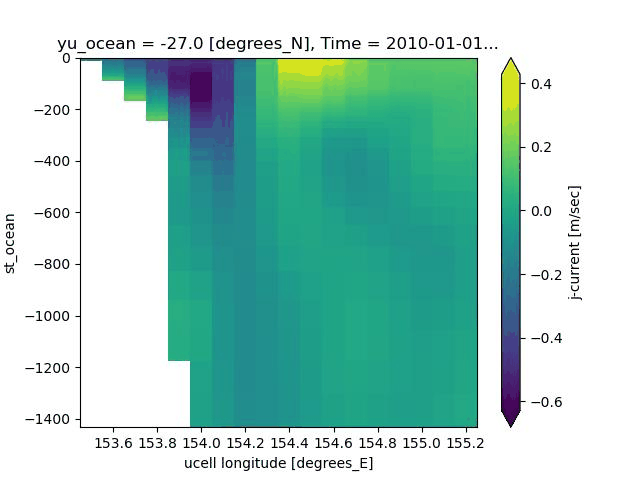

In [17]:
if __name__ == "__main__":
    v.streamjoy(dim='Time',max_frames=20,
                client=client,
                uri="/g/data/es60/users/thomas_moore/EAC_BRAN_slices/v_test.gif")

In [18]:
ds_combined = xr.Dataset({'u': u, 'v': v})

In [24]:
@wrap_matplotlib()
def renderer(ds):
    fig = plt.figure(figsize=(12, 6))  # Set the figure size to be wider
    
    fig.suptitle('BRAN2020: N/S & E/W EAC current at 27 South', fontsize=16)  # Add main title
    
    ax1 = fig.add_subplot(121)  # First subplot
    ax2 = fig.add_subplot(122)  # Second subplot
    
    # Create a colormap and set the 'bad' color for NaN values
    cmap = plt.cm.RdBu.copy()
    cmap.set_bad(color='grey')  # Set NaN color to black
    
    # Plot the data on the first subplot
    ds.sel(variable='v').plot(ax=ax1, vmin=-0.7, vmax=0.7, cmap=cmap, cbar_kwargs={'extend': 'neither'})
    
    # Plot the data on the second subplot
    ds.sel(variable='u').plot(ax=ax2, vmin=-0.7, vmax=0.7, cmap=cmap, cbar_kwargs={'extend': 'neither'})
    ax2.set_title('')  # Remove the title from the second plot
    ax2.set_ylabel('')  # Remove the x axis label from the second plot
    
    # Set any additional properties for the subplots
    
    return fig

    
stream(ds_combined.to_array(),renderer=renderer,dim='Time',max_frames=-1,
                client=client,
                uri="/g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_uv_02082024.mp4",
      threads_per_worker=1)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44571,Workers: 28
Dashboard: /proxy/8787/status,Total threads: 28
Started: 16 minutes ago,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:33893,Total threads: 1
Dashboard: /proxy/41985/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:36145,


2024-08-02 15:28:39,691 - distributed.utils_perf - WARNING - full garbage collections took 13% CPU time recently (threshold: 10%)
2024-08-02 15:28:41,447 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-08-02 15:28:41,905 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
[SUCCESS] 03:30PM: Saved stream to /g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_uv_02082024.mp4.


PosixPath('/g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_uv_02082024.mp4')

In [43]:
@wrap_matplotlib()
def renderer(da):
    fig = plt.figure(figsize=(12, 6))  # Set the figure size to be wider
    
    fig.suptitle('N/S current at 27 South', fontsize=16)  # Add main title
    
    ax1 = fig.add_subplot(111)  # First subplot

    # Create a colormap and set the 'bad' color for NaN values
    cmap = plt.cm.RdBu.copy()
    cmap.set_bad(color='grey')  # Set NaN color to black
    
    # Plot the data on the first subplot
    da.plot(ax=ax1, vmin=-0.7, vmax=0.7, cmap=cmap, cbar_kwargs={'extend': 'neither'})
    
    return fig

    
stream(v,renderer=renderer,dim='Time',max_frames=-1,
                client=client,
                uri="/g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_v.mp4",
      threads_per_worker=1)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.18 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40175,Workers: 28
Dashboard: /proxy/8787/status,Total threads: 28
Started: 1 hour ago,Total memory: 251.18 GiB
Comm: tcp://127.0.0.1:38101,Total threads: 1
Dashboard: /proxy/33225/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:34609,


2024-07-31 12:43:14,523 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 12:43:17,045 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 12:43:17,445 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 12:43:17,472 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 12:43:18,050 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 12:43:19,457 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 12:43:19,950 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 12:43:19,972 - distributed.utils_perf - WARNING - full garbage collections took

PosixPath('/g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_v.mp4')

In [46]:
@wrap_matplotlib()
def renderer(da):
    fig = plt.figure(figsize=(12, 6))  # Set the figure size to be wider
    
    fig.suptitle('E/W current at 27 South', fontsize=16)  # Add main title
    
    ax1 = fig.add_subplot(111)  # First subplot

    # Create a colormap and set the 'bad' color for NaN values
    cmap = plt.cm.RdBu.copy()
    cmap.set_bad(color='grey')  # Set NaN color to black
    
    # Plot the data on the first subplot
    da.plot(ax=ax1, vmin=-0.7, vmax=0.7, cmap=cmap, cbar_kwargs={'extend': 'neither'})
    
    return fig

    
stream(u,renderer=renderer,dim='Time',max_frames=-1,
                client=client,
                uri="/g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_u.mp4",
      threads_per_worker=1)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.18 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40175,Workers: 28
Dashboard: /proxy/8787/status,Total threads: 28
Started: 1 hour ago,Total memory: 251.18 GiB
Comm: tcp://127.0.0.1:38101,Total threads: 1
Dashboard: /proxy/33225/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:34609,


2024-07-31 13:14:47,217 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 13:14:49,887 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 13:14:51,846 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 13:14:55,385 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 13:14:57,666 - distributed.utils_perf - WARNING - full garbage collections took 12% CPU time recently (threshold: 10%)
2024-07-31 13:15:00,159 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 13:15:02,641 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-07-31 13:15:05,175 - distributed.utils_perf - WARNING - full garbage collections took

PosixPath('/g/data/es60/users/thomas_moore/EAC_BRAN_slices/EAC_u.mp4')